# Model Parameterization and Evaluation

## Metabolic Model Inputs

### Packages

In [1]:
# General
import pandas as pd
import numpy as np
import pandas as pd
import os
DATA_DIR = 'C:/Users/jakel/Desktop/Projects/Media_Prediction/media_prediction/'

# Pipeline
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

from sklearn.decomposition import PCA 
import umap
import hdbscan

from sklearn import metrics
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Visualization
from matplotlib import pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Dataset

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "notebooks", "ml_input.csv"), low_memory=False)

filter = df["ec"].str.contains("-") # filter non-specific ec numbers, e.g., 1.1.1.-
df = df[~filter]

df = df[["taxon_id", "media_id", "ec"]].value_counts().reset_index()
df = df.pivot(index=["taxon_id", "media_id"], columns="ec", values="count")
df = df.fillna(0.0).reset_index()

# Filtering into training and test sets (database set vs. MAGs)
bins = df["media_id"].str.contains("unknown")
df_train = df[~bins]

# Create a mapping from media_id to a float and apply to dataframe
#media_id_mapping = {media_id: float(i) for i, media_id in enumerate(df_train['media_id'].unique())}
#df_train['media_id_float'] = df_train["media_id"].map(media_id_mapping)

print(len(df_train), "samples")
df_train.head()

8464 samples


ec,taxon_id,media_id,1.1.1.1,1.1.1.100,1.1.1.101,1.1.1.102,1.1.1.103,1.1.1.105,1.1.1.107,1.1.1.108,...,7.6.2.12,7.6.2.13,7.6.2.14,7.6.2.15,7.6.2.16,7.6.2.2,7.6.2.5,7.6.2.7,7.6.2.8,7.6.2.9
0,100.0,J346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100.0,J386,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100225.0,J233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1002526.0,J22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1004166.0,1a,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
len(df_train)

8464

## Model

### Testing parameters

In [4]:
# Split the datasets into training and test sets
TARGET = "taxon_id" # target label "media_id"
RANDOM_SEED = 47 # seed for random_state

# Model validation with only labeled samples from data.ipynb
X_train, X_test, y_train, y_test = train_test_split(
    df_train.drop(["taxon_id", "media_id"], axis=1),
    df_train[TARGET],
    test_size=0.2,
    random_state=RANDOM_SEED
)

In [5]:
X1 = pd.DataFrame(X_train)
X2 = pd.DataFrame(X_test)
y1 = pd.DataFrame(y_train)
y2 = pd.DataFrame(y_test)

X1["Set"] = "Train"
X2["Set"] = "Test"
y1["Set"] = "Train"
y2["Set"] = "Test"

x_frames = X1, X2
y_frames = y1, y2

X_split = pd.concat(x_frames)
y_split = pd.concat(y_frames)

X_split.to_csv("~/Desktop/X_split.csv")
y_split.to_csv("~/Desktop/y_split.csv")

In [6]:
# Test a range of parameters for dimensionality reduction
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import make_scorer, silhouette_score

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('pca', PCA(
        n_components=150,
        random_state= RANDOM_SEED
        )),  
    ('umap', umap.UMAP(  
        metric="euclidean",
        n_epochs=500,
        random_state=RANDOM_SEED,
        n_jobs=1,
        ))
])

# Define parameter grid with correct step names
param_distributions = {
    'umap__n_components': range(2,50),
    'umap__n_neighbors': range(20,100), 
    'umap__min_dist': range(0,1)
}

# Custom scorer function
def umap_silhouette(X, y):
    embedding = X  # X here is already the transformed data by UMAP
    return silhouette_score(embedding, y)

# Wrap the custom scorer
scorer = make_scorer(umap_silhouette, greater_is_better=True)

# Initialize RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    scoring=scorer
)

# Fit the search to your data
#search.fit(X_train, y_train)
#best_params = search.best_params_
#best_model = search.best_estimator_

#print("Best Parameters:", best_params) 

### Pipeline

In [7]:
# sklearn pipeline helps prevent data leakage; incorporate best_params here
pipeline = Pipeline([
    ('scaler', StandardScaler()),    
    ('pca', PCA(
        n_components=150,
        random_state= RANDOM_SEED
        )), 
    ('umap', umap.UMAP(             
        metric="euclidean",
        n_epochs=500, 
        random_state=RANDOM_SEED,
        n_jobs=1,
        n_components=40, 
        n_neighbors=62, 
        min_dist=0
        )) 
])

# Fit and transform
X_train_transformed = pipeline.fit_transform(X_train) # fit pipeline and transform training data
X_test_transformed = pipeline.transform(X_test) # transform test data

### Optimizing n_clusters

In [8]:
# Silhouette coefficient method
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Test a range of clusters for their silhouette coefficients
#clusters = []
#for n_cluster in range(100, 300):
#    kmeans = KMeans(n_clusters=n_cluster).fit(X_train_transformed)
#    label = kmeans.labels_
#    sil_coeff = silhouette_score(X_train_transformed, label, metric='euclidean')
#    clusters.append({'n_clusters': n_cluster, 'coefficient': sil_coeff})

# Select the maximum coefficient
#clusters = pd.DataFrame(clusters)
#c = clusters.iloc[clusters["coefficient"].argmax()]["n_clusters"]
#s = clusters["coefficient"].max()
#n = int(c)+1

#print("{} clusters returns a maximum Silhouette Coefficient of {}".format(n, s))

In [9]:
# Cluster using maximum coefficient's n_clusters
clusterer = KMeans(n_clusters=182, random_state=RANDOM_SEED)
training_clusters = clusterer.fit_predict(X_train_transformed)
test_clusters = clusterer.predict(X_test_transformed)

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


### Metrics

In [10]:
# Initial dimensionality reduction performance (PCA)
pca = pipeline.named_steps['pca']
explained_variance = pca.explained_variance_ratio_
print(f"Total PCA explained variance: {explained_variance.sum()}")

# Further dimensionality reduction and clustering performance
silhouette_avg = silhouette_score(X_train_transformed, training_clusters)
print(clusterer.labels_.max()+1, "KMeans training clusters")
print(f"Average Silhouette Score on KMeans clusters: {silhouette_avg}")
    # Silhouette score <=0.25 implies poor clustering, 0.25<x<=0.50 is fair, <50 is good

#173, 0.73951; 178, 0.74609; 180, 0.74886; 185, 0.74425; 187, 0.74365; ... 223, 0.73052

Total PCA explained variance: 0.8869085094399858
182 KMeans training clusters
Average Silhouette Score on KMeans clusters: 0.6824479103088379


In [11]:
# Compare to hdbscan clustering 

# Apply HDBSCAN clustering on the transformed training data
hclusterer = hdbscan.HDBSCAN(
    min_samples=5, 
    min_cluster_size=15, 
    #gen_min_span_tree=True, 
    prediction_data=True # cluster_selection_method="leaf", for more fine-grained clustering
)
htraining_clusters = hclusterer.fit_predict(X_train_transformed)

# Clustering performance (UMAP and hdbscan)
hsilhouette_avg = silhouette_score(X_train_transformed, htraining_clusters)
print(hclusterer.labels_.max(), "hdbscan training clusters")
print(f"Silhouette Score on hdbscan clusters: {hsilhouette_avg}")

# Convert to numpy array for hdbscan and predict clustering
#test_points = test_df[["Component 1", "Component 2"]].to_numpy()
#test_labels, strengths = hdbscan.approximate_predict(clusterer, test_points)

# Optional constraints
#filtered = train_df[train_df['Cluster'] >= 0]
#test_labels = clusterer.fit_predict(X_test_transformed)

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


123 hdbscan training clusters
Silhouette Score on hdbscan clusters: 0.5063306093215942


## Classifier

In [12]:
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

In [13]:
y2_train = training_clusters
y2_test = test_clusters

### Random Forest

In [14]:
rfc = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

rfc.fit(X_train_transformed, y2_train)
print(rfc.predict(X_test_transformed))

[125  75  34 ... 175 132  68]


In [15]:
report = classification_report(
    y_true=y2_test,
    y_pred=rfc.predict(X_test_transformed),
    zero_division=0.0 # Default: set to "warn", or float {0.0, 1.0}
)

roc_score = metrics.roc_auc_score(
    y_true=y2_test,
    y_score=rfc.predict_proba(X_test_transformed),
    labels=np.unique(y2_train),
    average="weighted",
    multi_class="ovo"
)

print(report)
print("RF ROC AUC score:", roc_score)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       0.86      1.00      0.92        12
           2       1.00      0.67      0.80         6
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         4
           5       0.98      1.00      0.99        50
           6       1.00      0.75      0.86         4
           7       1.00      1.00      1.00        53
           8       1.00      1.00      1.00        44
           9       0.63      1.00      0.77        12
          10       1.00      1.00      1.00        43
          11       1.00      1.00      1.00         8
          12       1.00      1.00      1.00        18
          13       1.00      1.00      1.00        26
          14       1.00      0.86      0.92         7
          15       1.00      1.00      1.00        18
          16       1.00      1.00      1.00        26
          17       1.00    

### Nearest Neighbors

In [16]:
knc= KNeighborsClassifier(n_neighbors=1)
knc.fit(X_train_transformed, training_clusters)

X_test_reindexed = list(X_test_transformed) # is this mapping accurate?

distances, indices = knc.kneighbors(X_test_reindexed)

print(knc.predict(X_test_transformed))
indices

[125  75  34 ...  82 132  68]


array([[3686],
       [6206],
       [6453],
       ...,
       [6536],
       [6508],
       [6270]], shape=(1693, 1))

In [17]:
report = classification_report(
    y_true=y2_test,
    y_pred=knc.predict(X_test_transformed),
    zero_division=0.0 # Default: set to "warn", or float {0.0, 1.0}
)

roc_score = metrics.roc_auc_score(
    y_true=y2_test,
    y_score=knc.predict_proba(X_test_transformed),
    labels=np.unique(y2_train),
    average="weighted",
    multi_class="ovo"
)

print(report)
print("KNN ROC AUC score:", roc_score)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        12
           2       0.86      1.00      0.92         6
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         4
           5       0.98      1.00      0.99        50
           6       1.00      1.00      1.00         4
           7       1.00      1.00      1.00        53
           8       1.00      1.00      1.00        44
           9       1.00      1.00      1.00        12
          10       1.00      1.00      1.00        43
          11       1.00      1.00      1.00         8
          12       1.00      1.00      1.00        18
          13       1.00      1.00      1.00        26
          14       1.00      0.86      0.92         7
          15       1.00      1.00      1.00        18
          16       1.00      1.00      1.00        26
          17       1.00    

## Dataframes

In [18]:
# Training data
train_df = pd.DataFrame(X_train_transformed, columns=[f"Component {i+1}" for i in range(X_train_transformed.shape[1])])
train_df['Set'] = 'Training'
y_train_labels = list(y_train)
train_df['Target'] = y_train_labels
train_df['KMeans Cluster'] = training_clusters

# Media cluster labels
media_clusters = pd.read_csv(os.path.join(DATA_DIR, "data", "model", "media-clusters.csv"))
media_clusters = media_clusters[["media_id", "Media Cluster"]]
media_clusters = media_clusters.rename(columns={"media_id": "Target"})
target_label_mapping = dict(zip(media_clusters['Target'], media_clusters['Media Cluster']))
train_df['Media Cluster'] = train_df['Target'].map(target_label_mapping)

train_df.to_csv(os.path.join(DATA_DIR, "data", "model", "param-train-output.csv"), index=False)

print(len(train_df))
train_df.head()

6771


,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Component 10,...,Component 35,Component 36,Component 37,Component 38,Component 39,Component 40,Set,Target,KMeans Cluster,Media Cluster
0,16.496548,10.973616,3.114033,-6.937955,-4.924593,-0.260706,-21.151857,-3.230333,-18.709293,15.255355,...,5.327345,7.229095,1.814426,-5.505816,9.152301,3.277781,Training,2837493.0,84,NaN
1,10.676481,5.970467,3.474294,2.202261,4.315589,5.487319,2.142491,2.556231,2.737488,6.324217,...,5.858292,5.355815,5.093126,6.470603,5.738785,2.865534,Training,50422.0,47,NaN
2,24.460833,25.459335,11.257106,2.595399,-3.707609,-15.375215,-21.696548,17.744408,-25.631138,8.740919,...,1.040777,7.378432,-4.632226,-3.347457,12.699204,8.671677,Training,41899.0,146,NaN
3,19.847162,7.295486,-6.747349,2.776625,5.394870,0.864545,13.606570,-7.848526,10.255764,11.637768,...,14.228336,-3.426263,12.631971,3.548046,2.224578,-7.625549,Training,433287.0,4,NaN
4,24.836557,25.511337,11.272011,2.691456,-4.058197,-14.888627,-22.271982,17.707300,-25.290686,9.006761,...,0.854786,7.245287,-4.110073,-3.572022,13.045759,8.723322,Training,2725666.0,112,NaN


In [19]:
# Test data
test_df = pd.DataFrame(X_test_transformed, columns=[f"Component {i+1}" for i in range(X_test_transformed.shape[1])])
test_df['Set'] = 'Test'
y_test_labels = list(y_test)
test_df['Target'] = y_test_labels
test_df['KMeans Cluster'] = test_clusters

# Add classifier labels 
test_df["KNN Classify"] = knc.predict(X_test_transformed)
test_df["RF Classify"] = rfc.predict(X_test_transformed)

test_df.to_csv(os.path.join(DATA_DIR, "data", "model", "param-test-output.csv"), index=False)

print(len(test_df))
test_df.head()

1693


,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Component 10,...,Component 36,Component 37,Component 38,Component 39,Component 40,Set,Target,KMeans Cluster,KNN Classify,RF Classify
0,7.444254,8.598090,14.716700,7.656519,7.020383,2.880068,3.357966,5.147837,5.168786,4.657511,...,5.506262,4.746781,5.502570,5.236891,4.530361,Test,2656774.0,125,125,125
1,15.328052,5.554193,1.730233,0.884514,8.016017,11.449446,-3.124146,3.144865,3.134956,2.361862,...,8.017212,2.763797,10.417040,5.503402,12.934187,Test,861298.0,75,75,75
2,24.810778,25.379442,10.821229,3.315625,-3.569003,-14.839955,-21.974020,18.893105,-24.846489,8.846927,...,6.272021,-3.610460,-2.313725,12.890066,8.804206,Test,1424653.0,34,34,34
3,24.441027,25.474405,11.239191,2.665111,-3.638098,-15.366417,-21.688147,17.808163,-25.608238,8.695703,...,7.401426,-4.628891,-3.455037,12.551908,8.627555,Test,2291845.0,149,149,149
4,24.970278,25.320616,10.796926,3.198417,-3.698213,-14.877975,-21.916790,18.643570,-25.059378,8.895665,...,6.411013,-3.510681,-2.541230,12.824116,8.793590,Test,80867.0,105,175,175


In [20]:
# Add nearest neighbor indices to the test dataframe
knn_df = test_df.copy()
knn_df = knn_df.rename(columns={"KMeans Cluster": "Test Cluster"})
neighbors = pd.DataFrame(indices) # Indices of nearest neighbors from the training set
knn_df['indices'] = neighbors[neighbors.columns[0:]].apply(lambda x: ';'.join(x.dropna().astype(str)), axis=1)
knn_df["indices"] = knn_df["indices"].str.split(';')
knn_df = knn_df.explode("indices")

# Add original indices as a column for the train dataframe
    # Index maps to original dataframe before train_test_split!
    # Randomizes => inaccurate nearest neighbor mapping based on indices (fine if X_test and X_train are defined as in 05-Model-Test)
train_index = train_df.copy()
train_index = train_index.rename(columns={"KMeans Cluster": "Train Cluster"})
y_train_labels = pd.DataFrame(y_train).reset_index() # reset of index, TODO: ensure this is correct mapping!
train_index["indices"] = y_train_labels.index 
train_index["indices"] = train_index["indices"].astype(str)

# Merge to label nearest neighbors
left = knn_df.copy()
right = train_index[["indices", "Target", "Media Cluster"]] #"taxon_id", 
right = right.rename(columns={"Target": "neighbor_media_id", "Train Cluster": "neighbor_cluster", "Media Cluster": "neighbor_media_cluster"})
merged = pd.merge(left, right, on="indices", how="left")

merged.to_csv(os.path.join(DATA_DIR, "data", "model", "param-model-output.csv"), index=False)
merged

,Component 1,Component 2,Component 3,Component 4,Component 5,Component 6,Component 7,Component 8,Component 9,Component 10,...,Component 39,Component 40,Set,Target,Test Cluster,KNN Classify,RF Classify,indices,neighbor_media_id,neighbor_media_cluster
0,7.444254,8.598090,14.716700,7.656519,7.020383,2.880068,3.357966,5.147837,5.168786,4.657511,...,5.236891,4.530361,Test,2656774.0,125,125,125,3686,2306585.0,NaN
1,15.328052,5.554193,1.730233,0.884514,8.016017,11.449446,-3.124146,3.144865,3.134956,2.361862,...,5.503402,12.934187,Test,861298.0,75,75,75,6206,434086.0,NaN
2,24.810778,25.379442,10.821229,3.315625,-3.569003,-14.839955,-21.974020,18.893105,-24.846489,8.846927,...,12.890066,8.804206,Test,1424653.0,34,34,34,6453,2714355.0,NaN
3,24.441027,25.474405,11.239191,2.665111,-3.638098,-15.366417,-21.688147,17.808163,-25.608238,8.695703,...,12.551908,8.627555,Test,2291845.0,149,149,149,6466,67348.0,NaN
4,24.970278,25.320616,10.796926,3.198417,-3.698213,-14.877975,-21.916790,18.643570,-25.059378,8.895665,...,12.824116,8.793590,Test,80867.0,105,175,175,5960,53317.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688,22.146824,21.314758,9.093212,-0.467880,-4.333300,-10.883287,-21.699255,11.242079,-23.797930,10.777000,...,11.859639,6.998254,Test,54571.0,150,150,73,1996,1685.0,NaN
1689,24.681520,25.434904,11.050386,2.924265,-3.650442,-15.062265,-22.029446,18.309065,-25.073856,8.831641,...,12.782543,8.770862,Test,1982043.0,96,96,96,3153,2282700.0,NaN
1690,24.975344,25.323553,10.778893,3.294440,-3.673811,-14.887049,-21.860207,18.657290,-25.149496,8.865630,...,12.813643,8.784299,Test,83655.0,82,82,175,6536,79270.0,NaN
1691,19.879591,7.192973,-6.889038,2.806761,5.454616,0.854010,13.691034,-7.899814,10.395845,11.743058,...,2.114168,-7.723471,Test,60133.0,132,132,132,6508,840.0,NaN


## Feature Importance

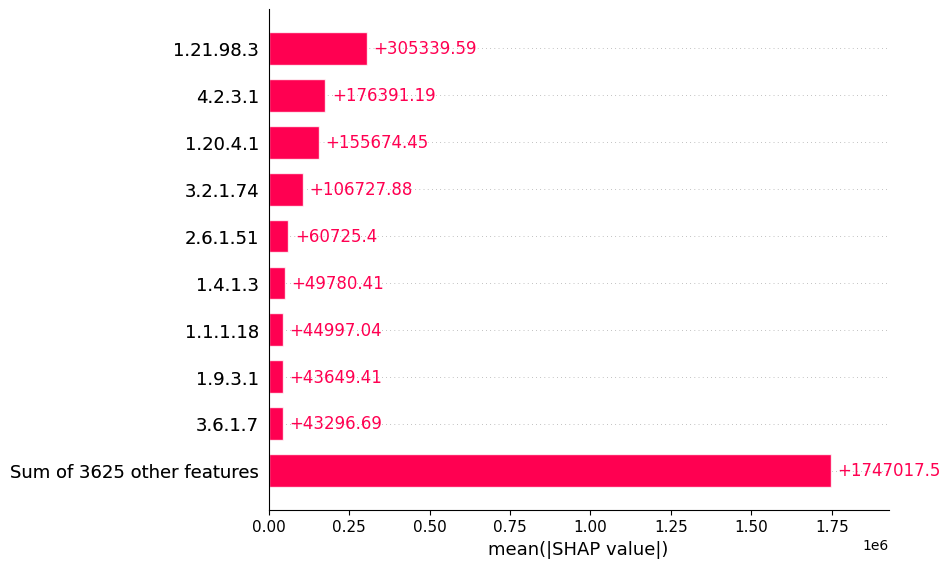

In [21]:
import xgboost
import shap

XG_train = df_train.drop(["taxon_id", "media_id"], axis=1)
yG_train = df_train["taxon_id"]

df_test = df[bins]
XG_test = df_test.drop(["taxon_id", "media_id"], axis=1)
yG_test = df_test["taxon_id"]

# train an XGBoost model
model = xgboost.XGBRegressor().fit(XG_train, yG_train)

# explain the model's predictions using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(XG_test)

shap.plots.initjs()
#shap.plots.beeswarm(shap_values, max_display=11)
shap.plots.bar(shap_values, max_display=10)

[Text(0, 0, '   +305339.59'),
 Text(0, 0, '   +176391.19'),
 Text(0, 0, '   +155674.45'),
 Text(0, 0, '   +106727.88'),
 Text(0, 0, '   +60725.4'),
 Text(0, 0, '   +49780.04'),
 Text(0, 0, '   +44997.04'),
 Text(0, 0, '   +43649.41'),
 Text(0, 0, '   +43296.69'),
 Text(0, 0, '   +1747017.5')]

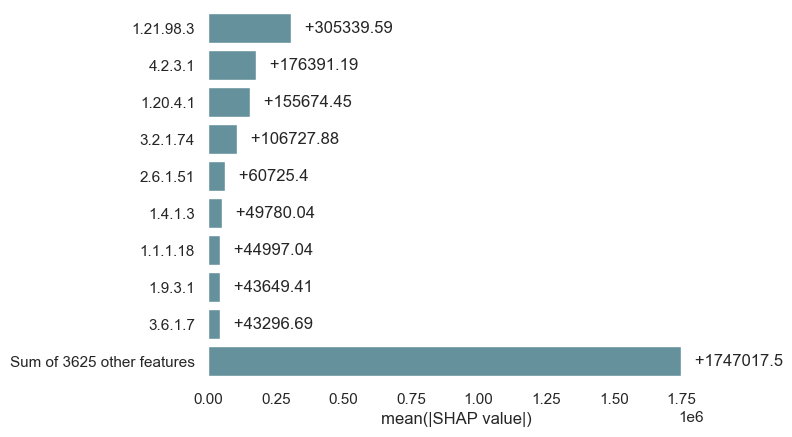

In [22]:
dict = {
    "features": ["1.21.98.3","4.2.3.1", "1.20.4.1", "3.2.1.74", "2.6.1.51", "1.4.1.3", "1.1.1.18", "1.9.3.1", "3.6.1.7", "Sum of 3625 other features"], #"4.1.1.17", 
    "importance": [305339.59, 176391.19, 155674.45, 106727.88, 60725.4, 49780.04, 44997.04, 43649.41, 43296.69, 1747017.5] #38625, 1708392.5
}

df = pd.DataFrame(dict)

df["labels"] = df["importance"].astype(str)
df["labels"] = "   +" + df["labels"]

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
f, ax = plt.subplots()

sns.barplot(x="importance", y="features", data=df, color="#5c96a5")

ax.set(ylabel="", xlabel="mean(|SHAP value|)")
sns.despine(left=True, bottom=True)
ax.bar_label(ax.containers[0], labels=df["labels"])

# Media Model

In [ ]:
#TODO: figure out where all these media model dataframes went/came from

In [24]:
# Load dataframe
media_df = pd.read_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-complete-explo.csv"), low_memory=False)
media_df = media_df[["media_id", "component_ids"]]


df = media_df[["media_id", "component_ids"]].value_counts().reset_index()
df = df.pivot(index="media_id", columns="component_ids", values="count")
df = df.fillna(0.0)
df = df.map(lambda x: 1.0 if x > 0 else 0.0).reset_index() # make binary

df = df.drop(4.0, axis=1) # drop water as an ingredient, consider other "universal" features, or use sklearn "feature selection"

df

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/jakel/Desktop/Projects/Media_Prediction/media_prediction/data\\mediadive\\mediadive-complete-explo.csv'

In [ ]:
import umap

reducer = umap.UMAP(             
    metric="euclidean",
    n_epochs=500, 
    random_state=RANDOM_SEED,
    n_jobs=1,
    n_components=2, #13
    n_neighbors=73, #97
    min_dist=0 #0
)

# Fit and transform
X_train_transformed = reducer.fit_transform(df.drop("media_id", axis=1)) 

In [ ]:
# Cluster 
clusterer = KMeans(n_clusters=23, random_state=RANDOM_SEED)
training_clusters = clusterer.fit_predict(X_train_transformed)
silhouette_avg = silhouette_score(X_train_transformed, training_clusters)
print(clusterer.labels_.max()+1, "KMeans training clusters")
print(f"Average Silhouette Score on KMeans clusters: {silhouette_avg}")

# Dataframe
train_df = pd.DataFrame(X_train_transformed, columns=[f"Component {i+1}" for i in range(X_train_transformed.shape[1])])
y_train_labels = list(df["media_id"])
train_df['Target'] = y_train_labels
train_df['KMeans Cluster'] = training_clusters

print(len(train_df), "training points")

23 KMeans training clusters
Average Silhouette Score on KMeans clusters: 0.5506554245948792
3134 training points


c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


In [ ]:
#palette=["#2BD8D8", "#FCB019"]
#palette=["#FC0B0B", "#F5B139"] 
#palette=["#0772A7", "#F5B139"] # palette for two clusters

fig = px.scatter(
    data_frame = train_df,
    x = "Component 1",
    y = "Component 2", 
    color = "KMeans Cluster",
    hover_data = ["Target"],
    #color_continuous_scale=px.colors.diverging.Picnic_r
    #color_continuous_scale=palette
    #opacity = 0.3
) 

fig.update_coloraxes(showscale=False) # hide color bar
fig.update_layout(
    template="plotly_white",
    showlegend=False,
    #width=500, 
    #height=500
)

fig.show()

In [ ]:
# Saving the media clusters to a df for labeling other ml outputs
train_df = train_df.rename(columns={"Target": "media_id", "KMeans Cluster": "Media Cluster"})
train_df = train_df.drop(["Component 1", "Component 2"], axis=1)
#train_df.to_csv(os.path.join(DATA_DIR, "model", "media-clusters.csv"), index=False)
train_df.head()

,media_id,Media Cluster
0,1,9
1,10,19
2,1000,5
3,1001,2
4,1002,11
